## Results evaluated at different locations, for pipe 0.2 meters long and for 57000 mesh cells

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def get_velocity_of(path):
     #return velocity for data which got from openFoam sampling
    data = pd.read_csv(path)
    data.dropna()

    data['U'] = np.sqrt(data['U_1']**2 + data['U_2']**2 + data['U_0']**2) # velocity magnitude
    return data

def get_velocity_pv(path):
    #return velocity for data which got from paraView
    data = pd.read_csv(path)
    data.dropna()

    data['U'] = np.sqrt(data['U:1']**2 + data['U:2']**2 + data['U:0']**2) # velocity magnitude
    return data

In [3]:
analytical_pv = get_velocity_pv('data/paraview_sampling/57k_cells_mesh_at_004.csv')
analytical_pv.head()

,p,U:0,U:1,U:2,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2,U
0,1.8704,0.000000e+00,0.000000e+00,0.000000,1,0.000000,0,-0.002270,0.04,0.000000
1,1.8704,3.068500e-20,6.817400e-07,0.003851,1,0.000005,0,-0.002266,0.04,0.003851
2,1.8704,5.266100e-20,1.363500e-06,0.007703,1,0.000009,0,-0.002261,0.04,0.007703
3,1.8704,6.745800e-20,2.045200e-06,0.011554,1,0.000014,0,-0.002256,0.04,0.011554
4,1.8704,7.604800e-20,2.727000e-06,0.015406,1,0.000018,0,-0.002252,0.04,0.015406


In [4]:
#radius
pressureGrad = 12.02186397801387
R = 0.00227 
r1 = np.linspace(-0.00227,0.00227,1001)

analytical_pv['r'] = np.sqrt(analytical_pv['Points:0']**2 + analytical_pv['Points:1']**2) # array how radius changing

analytical_pv['exp']=(R**2-r1**2)*(1/(4*1.48e-05))*pressureGrad 

In [5]:
x = np.arange(0,len(analytical_pv),1)

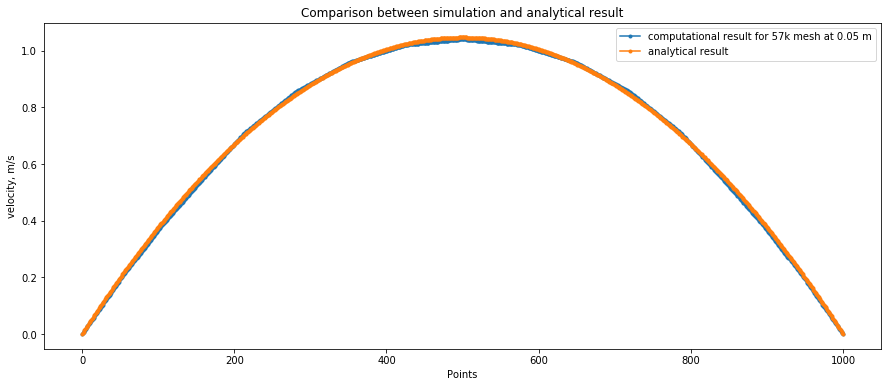

In [9]:
plt.figure(figsize=(15,6))
plt.plot(x,analytical_pv['U'],label = 'computational result for 57k mesh at 0.05 m', marker = '.')
plt.plot(x,analytical_pv['exp'], label = 'analytical result',marker = '.')
plt.title('Comparison between simulation and analytical result')
plt.xlabel('Points')
plt.ylabel('velocity, m/s')
plt.legend(loc="upper right");

In [10]:
print('Max velocity for analytical case {:2.6}'.format(max(analytical_pv['exp'])))
print('Max velocity for 57k cells case {:2.6}'.format(max(analytical_pv['U'])))

Max velocity for analytical case 1.04641
Max velocity for 57k cells case 1.0408


In [8]:
sampling_pv = pd.DataFrame()
location = ['002','004','006','008','01','012','014','016','018', '02']
for i in location:
    name = 'data/paraview_sampling/57k_cells_mesh_at_'+i+'.csv'
    sampling_pv[i] = get_velocity_pv(name)['U']

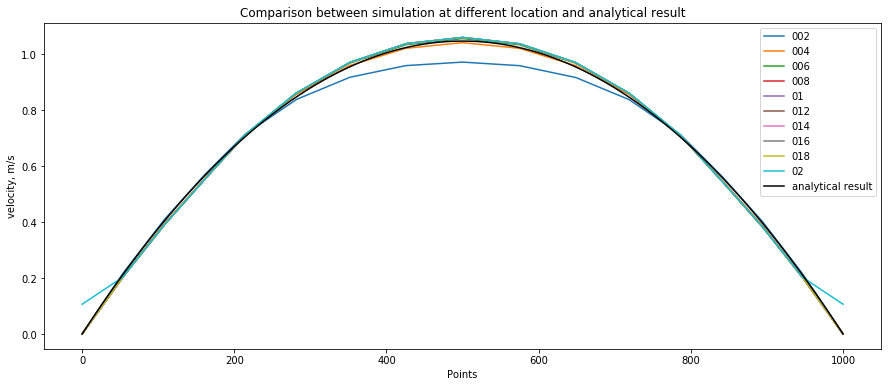

In [9]:
plt.figure(figsize=(15,6))

for i in location:
    plt.plot(x, sampling_pv[i], label = i)
plt.plot(x,analytical_pv['exp'], label = 'analytical result', color = 'black', linestyle ='-')
plt.title('Comparison between simulation at different location and analytical result')
plt.xlabel('Points')
plt.ylabel('velocity, m/s')
plt.legend(loc="upper right");

In [29]:
pv_max_vel = []
for i in location:
    pv_max_vel.append(max(sampling_pv[i]))
    print('Max velocity at location {} is {:2.6}'.format(i,max(sampling_pv[i])))

Max velocity at location 002 is 0.97126
Max velocity at location 004 is 1.0408
Max velocity at location 006 is 1.0552
Max velocity at location 008 is 1.0584
Max velocity at location 01 is 1.0591
Max velocity at location 012 is 1.0592
Max velocity at location 014 is 1.0593
Max velocity at location 016 is 1.0593
Max velocity at location 018 is 1.0593
Max velocity at location 02 is 1.0593


# Same case, results directly from OF

In [30]:
sampling_of = pd.DataFrame()
#location = ['002','004','006','008','01','012','014','016','018', '02']
for i in location:
    name = 'data/sample_from_OF/at0.'+i[1:]+'_U.csv'
    sampling_of[i] = get_velocity_of(name)['U']
    
of_max_vel = []   
for i in location:
    of_max_vel.append(max(sampling_of[i]))
    print('Max velocity at location {} is {:2.6}'.format(i,max(sampling_of[i])))

Max velocity at location 002 is 0.968906
Max velocity at location 004 is 1.04126
Max velocity at location 006 is 1.05513
Max velocity at location 008 is 1.05837
Max velocity at location 01 is 1.05909
Max velocity at location 012 is 1.05927
Max velocity at location 014 is 1.05927
Max velocity at location 016 is 1.05928
Max velocity at location 018 is 1.05928
Max velocity at location 02 is 1.05928


# get data with PyVista

In [31]:
import pyvista

points = np.arange(0.01, 0.2, 0.02)

pyVista_res_l2 = pd.DataFrame()
pyVista_res_l2['points'] = points
pyVista_res_l2.set_index('points', inplace = True)

def get_sample_data(path):
    filename = path + '.vtk'
    mesh = pyvista.read(filename)
    mesh.sample_over_line((0, -0.00227, 0.09),(0, 0.00227, 0.09))
    sample = [] 
    for i in points:
         sample.append(mesh.sample_over_line((0, -0.00227, i),(0, 0.00227, i), resolution=30)['U'].max())#resolution=15
    return sample

In [32]:
pyVista_res_l2= get_sample_data('/data/ri_extr/channel_57k_cells') 

pyvista_max_vel = []
for i in range(0,len(location)):
    pyvista_max_vel.append(pyVista_res_l2[i])
    print('Max velocity at location {} is {:2.6}'.format(location[i],pyVista_res_l2[i]))

Max velocity at location 002 is 0.858859
Max velocity at location 004 is 1.0193
Max velocity at location 006 is 1.05065
Max velocity at location 008 is 1.05738
Max velocity at location 01 is 1.05886
Max velocity at location 012 is 1.05919
Max velocity at location 014 is 1.05926
Max velocity at location 016 is 1.05928
Max velocity at location 018 is 1.05928
Max velocity at location 02 is 1.05928


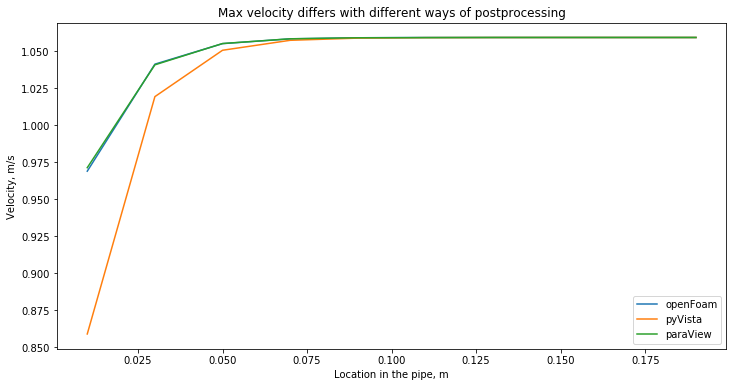

In [46]:
plt.figure(figsize=(12,6))

plt.plot(points,of_max_vel, label = 'openFoam')
plt.plot(points,pyvista_max_vel, label = 'pyVista')
plt.plot(points,pv_max_vel, label = 'paraView')
plt.xlabel('Location in the pipe, m')
plt.ylabel('Velocity, m/s')
plt.title('Max velocity differs with different ways of postprocessing')
plt.legend(loc="lower right");

## We can see that post processing data differs for each type of postprocessing. If we want to be fully reproducible we need to use same tools for post processing, overwise it will be not consistent.